In [534]:
import pandas as pd
import numpy as np
import matplotlib as plt

DATA PREPROCESSING

In [535]:
data=pd.read_csv("HousingData.csv")
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [536]:
data.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [537]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [538]:
data.shape


(506, 14)

In [539]:
from sklearn.impute import SimpleImputer, KNNImputer
#knn_imputer = KNNImputer(n_neighbors=5)
num_imputer = SimpleImputer(strategy='median')
num_cols = data.drop(columns=['CHAS', 'MEDV']).columns
data[num_cols] = num_imputer.fit_transform(data[num_cols])
cat_cols = ['CHAS']
data[num_cols] = num_imputer.fit_transform(data[num_cols])
cat_imputer = SimpleImputer(strategy='most_frequent')
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

In [540]:
'''data['CRIM'].fillna(data['CRIM'].mean(),inplace=True)
data['ZN'].fillna(data['ZN'].mean(),inplace=True)
data['INDUS'].fillna(data['INDUS'].mean(),inplace=True)
data['CHAS'].fillna(data['CHAS'].mode()[0],inplace=True)
data['AGE'].fillna(data['AGE'].mean(),inplace=True)
data['LSTAT'].fillna(data['LSTAT'].mean(), inplace=True)
data.head()'''


"data['CRIM'].fillna(data['CRIM'].mean(),inplace=True)\ndata['ZN'].fillna(data['ZN'].mean(),inplace=True)\ndata['INDUS'].fillna(data['INDUS'].mean(),inplace=True)\ndata['CHAS'].fillna(data['CHAS'].mode()[0],inplace=True)\ndata['AGE'].fillna(data['AGE'].mean(),inplace=True)\ndata['LSTAT'].fillna(data['LSTAT'].mean(), inplace=True)\ndata.head()"

In [541]:
data['LSTAT'] = np.log(data['LSTAT'] + 1)
data['CRIM'] = np.sqrt(data['CRIM'])

In [542]:
data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [543]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


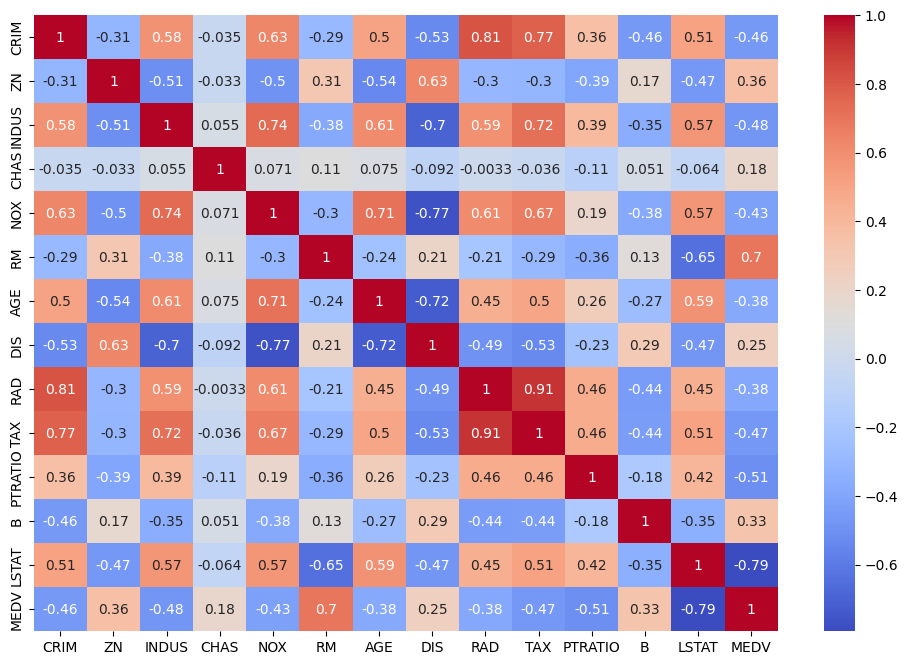

In [544]:
import seaborn as sns
import matplotlib.pyplot as plt 
corr_matrix=data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [545]:
from sklearn.ensemble import RandomForestRegressor
clf = RandomForestRegressor(n_estimators=100, random_state=42)
x= data.drop(columns=['MEDV'])
y=data['MEDV']

clf.fit(x, y)
features_imp=clf.feature_importances_
features =x.columns
feature_imp_df=pd.DataFrame({'features': features, 'importance': features_imp})
importance_df = feature_imp_df.sort_values(by='importance', ascending=False)

In [546]:
importance_df

,features,importance
5,RM,0.491484
12,LSTAT,0.303044
7,DIS,0.068490
0,CRIM,0.041833
4,NOX,0.024901
10,PTRATIO,0.017803
9,TAX,0.015022
6,AGE,0.013572
11,B,0.011412
2,INDUS,0.006621


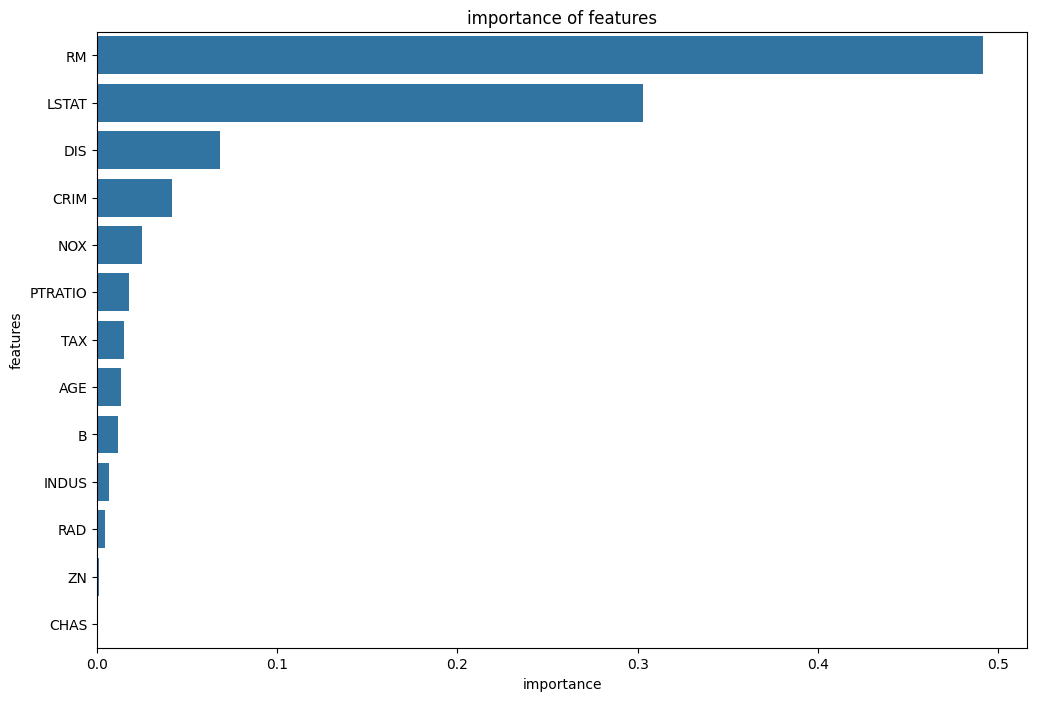

In [547]:
plt.figure(figsize=(12,8))
sns.barplot(x='importance',y='features',data=importance_df)
plt.title("importance of features")
plt.show()

In [548]:
#data=data.drop(columns=['CHAS'])
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.079498,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,1.788421,24.0
1,0.165257,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,2.316488,21.6
2,0.165197,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,1.615420,34.7
3,0.179917,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,1.371181,33.4
4,0.262774,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,2.520113,36.2


DATA VISUALISATION

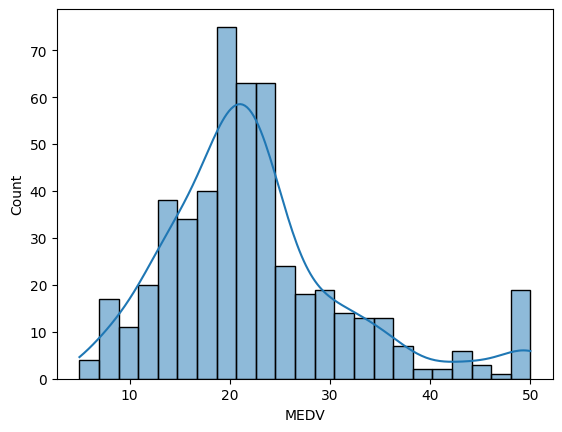

In [549]:
sns.histplot(data['MEDV'], kde=True)
plt.show()

data spliting

In [550]:
from sklearn.model_selection import train_test_split
x = data.drop(columns='MEDV')
y = data['MEDV'] 
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20)


In [551]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(x_train,y_train)
pred= lr.predict(x_test)

In [552]:
from sklearn.metrics import mean_squared_error, r2_score
mse_lr = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

In [553]:
print({f"mean square error : {mse_lr}"})
print({f"r2 score : {r2}"})

{'mean square error : 20.321018894879938'}
{'r2 score : 0.7228968966396572'}


In [554]:
from sklearn.model_selection import cross_val_score

clf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(clf, x, y, cv=5, scoring='r2')
print("Mean R² from 5-fold CV:", scores.mean())

Mean R² from 5-fold CV: 0.6402005334285098


visualization

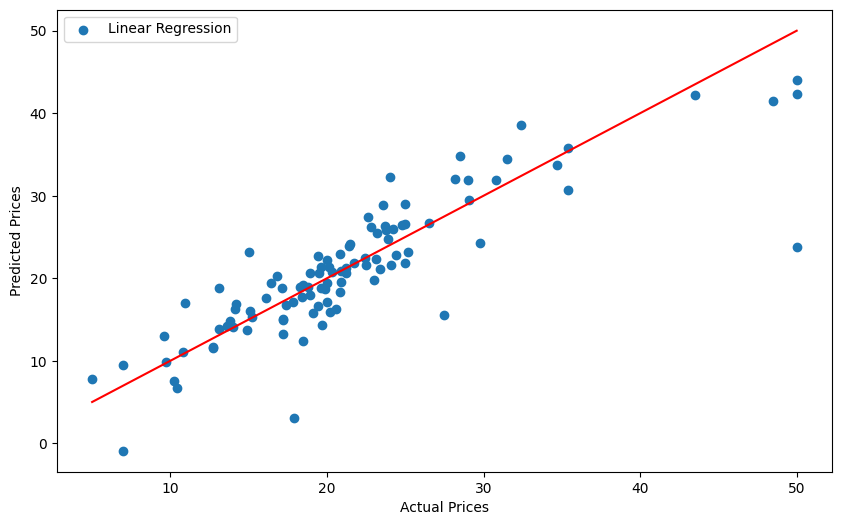

In [555]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, label='Linear Regression')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()

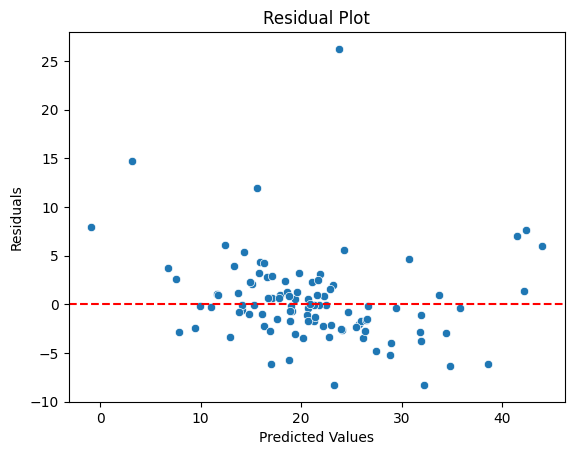

In [556]:
residuals = y_test - pred
sns.scatterplot(x=pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

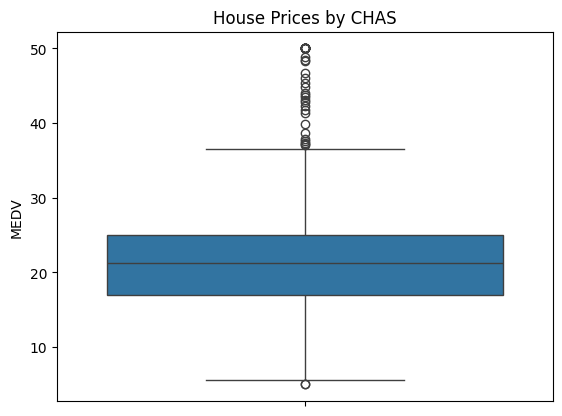

In [557]:
sns.boxplot( y='MEDV', data=data)
plt.title('House Prices by CHAS')
plt.show()